**Week 2 Jupyter Notebook**

**Integrated Capstone Project:** Systemic Banking Risk Assessment


**Objective**

The purpose of this notebook is to investigate regularization techniques that improve predictive performance and address potential overfitting in regression models. Specifically, Ridge, Lasso, and Elastic Net regression are applied to borrower financial data to predict loan amount and identify the most important predictors.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

In [19]:
# Load Cleaned Dataset

credit_risk = pd.read_csv("credit_risk_cleaned.csv")

credit_risk.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [20]:
# Select Variables

features = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

target = 'loan_amnt'

In [21]:
# Handle Missing Values

data = credit_risk[
    features + [target]
].copy()

data = data.dropna()

In [22]:
# Define X and y

X = data[features]

y = data[target]

In [23]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [24]:
# Standardize Variables

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [25]:
# Baseline Linear Regression

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

linear_pred = linear_model.predict(
    X_test_scaled
)

print(
    "Linear Regression R²:",
    r2_score(y_test, linear_pred)
)

print(
    "Linear Regression RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            linear_pred
        )
    )
)

Linear Regression R²: 0.571637043075304
Linear Regression RMSE: 4173.106539001964


In [26]:
# Ridge Regression

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_scaled,
    y_train
)

ridge_pred = ridge_model.predict(
    X_test_scaled
)

print(
    "Ridge R²:",
    r2_score(
        y_test,
        ridge_pred
    )
)

print(
    "Ridge RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            ridge_pred
        )
    )
)

Ridge R²: 0.5716289582836107
Ridge RMSE: 4173.1459197856475


In [27]:
# Ridge Coefficients

ridge_coef = pd.DataFrame({
    'Feature': features,
    'Coefficient': ridge_model.coef_
})

print(ridge_coef)

                      Feature  Coefficient
0                  person_age  -267.419840
1               person_income  2549.470380
2           person_emp_length   635.567989
3               loan_int_rate   452.644371
4         loan_percent_income  4234.048479
5  cb_person_cred_hist_length   234.190005


In [28]:
# Lasso Regression

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(
    X_train_scaled,
    y_train
)

lasso_pred = lasso_model.predict(
    X_test_scaled
)

print(
    "Lasso R²:",
    r2_score(
        y_test,
        lasso_pred
    )
)

print(
    "Lasso RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            lasso_pred
        )
    )
)

Lasso R²: 0.5716327062333115
Lasso RMSE: 4173.12766367857


In [29]:
# Lasso Coefficients

lasso_coef = pd.DataFrame({
    'Feature': features,
    'Coefficient': lasso_model.coef_
})

print(lasso_coef)

                      Feature  Coefficient
0                  person_age  -266.749978
1               person_income  2549.453461
2           person_emp_length   635.477696
3               loan_int_rate   452.549183
4         loan_percent_income  4234.122768
5  cb_person_cred_hist_length   233.542004


In [30]:
# Elastic Net Regression

elastic_model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5
)

elastic_model.fit(
    X_train_scaled,
    y_train
)

elastic_pred = elastic_model.predict(
    X_test_scaled
)

print(
    "Elastic Net R²:",
    r2_score(
        y_test,
        elastic_pred
    )
)

print(
    "Elastic Net RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            elastic_pred
        )
    )
)

Elastic Net R²: 0.5603189049124107
Elastic Net RMSE: 4227.877688882248


In [31]:
# Elastic Net Coefficients

elastic_coef = pd.DataFrame({
    'Feature': features,
    'Coefficient': elastic_model.coef_
})

print(elastic_coef)

                      Feature  Coefficient
0                  person_age  -165.240132
1               person_income  2365.097386
2           person_emp_length   610.215677
3               loan_int_rate   457.559783
4         loan_percent_income  3989.489853
5  cb_person_cred_hist_length   155.840736


In [32]:
# Compare Model Performance

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge',
        'Lasso',
        'Elastic Net'
    ],
    'R²': [
        r2_score(y_test, linear_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, elastic_pred)
    ]
})

results

,Model,R²
0,Linear Regression,0.571637
1,Ridge,0.571629
2,Lasso,0.571633
3,Elastic Net,0.560319


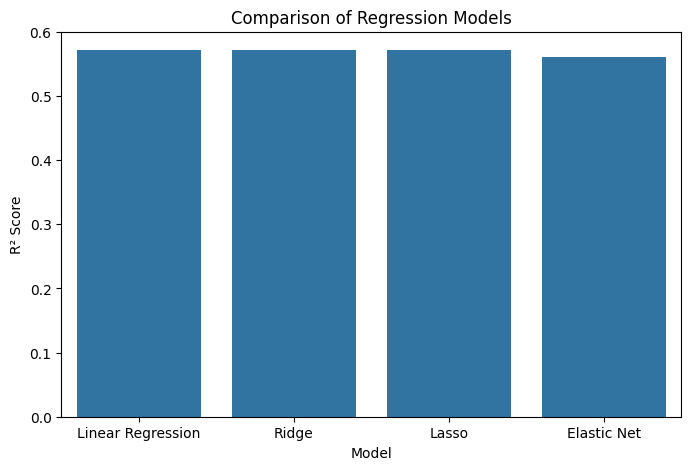

In [33]:
# Visualization: Model Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='R²'
)

plt.title(
    "Comparison of Regression Models"
)

plt.ylabel("R² Score")

plt.show()

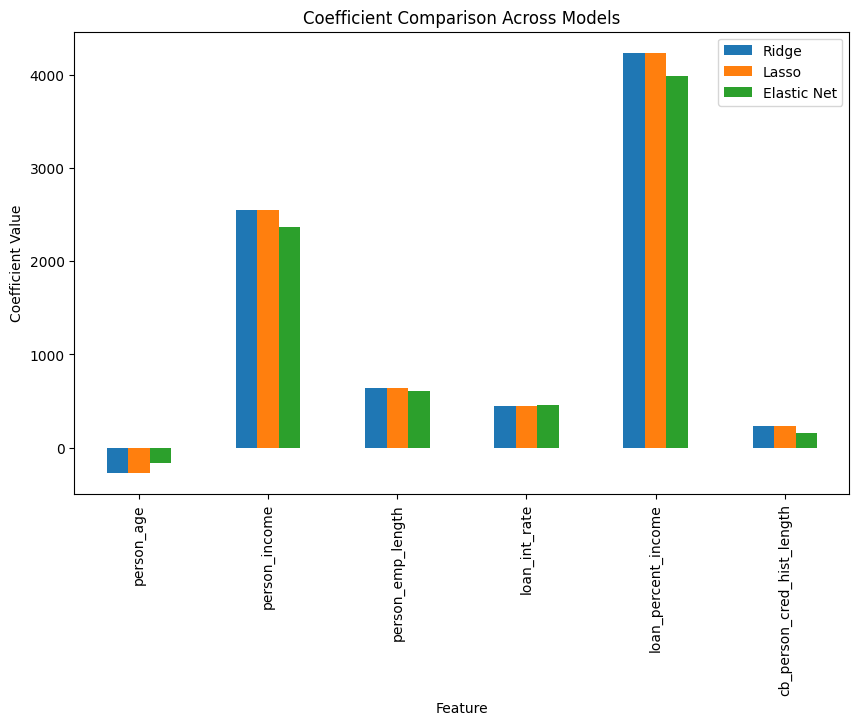

In [34]:
# Visualization: Coefficient Comparison

coef_df = pd.DataFrame({
    'Feature': features,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_,
    'Elastic Net': elastic_model.coef_
})

coef_df.set_index(
    'Feature'
).plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    "Coefficient Comparison Across Models"
)

plt.ylabel(
    "Coefficient Value"
)

plt.show()

**Conclusion**

The Week 2 analysis compared Linear Regression, Ridge Regression, Lasso Regression, and Elastic Net Regression for predicting loan amounts. All models performed similarly, with Linear Regression, Ridge, and Lasso achieving an R² of approximately 0.57, meaning they explained about 57% of the variation in loan amounts. Elastic Net performed slightly worse with an R² of 0.56 and a higher RMSE.

Among the predictors, loan percent income was the most influential variable, followed by borrower income, indicating that a borrower's debt burden and financial capacity are the strongest determinants of loan amount. Employment length, interest rate, and credit history length also had positive effects, while age showed a relatively small negative relationship with loan amount.

The similarity in performance across Linear Regression, Ridge, and Lasso suggests that multicollinearity is not a major issue in the dataset and that all selected predictors contribute useful information. Lasso did not eliminate any variables, indicating that each predictor provides value in explaining loan amounts.

Overall, the findings demonstrate that borrower income and loan burden are the most important factors influencing loan amounts. Regularization techniques provided stable and consistent results, establishing a strong foundation for future credit risk modeling and machine learning analyses in the capstone project.